## Week 5: Tweaks & Periodic Boundary Conditions 

In [1]:
#libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from IPython.display import HTML
import random

In [2]:
#Code from week 4

def LennardParticleEngine(kx=1, ky=1, mass=1, particles=2, boltzmann=1, gamma=0.1, target_temp=1.0, dt=0.001, total_time=5, 
                        rand_position_scale=1, rand_velocity_scale=1, epsilon = 1.0, lennard_sigma = 1.0):
    
    D = 2
    omega = np.sqrt(kx/mass) ; timestep = dt*omega
    snapshots = int(np.floor(total_time / timestep)) + 1

    time = np.arange(snapshots, dtype=float) * timestep 
    energy = np.zeros(snapshots, dtype=float) ; ke_list = np.zeros(snapshots, dtype=float)
    x_2d = np.zeros((snapshots, particles, D), dtype=float) ; v_2d = np.zeros((snapshots, particles, D), dtype=float)
    force_2d = np.zeros((snapshots, particles, D), dtype=float) ; temperature = np.zeros(v_2d.size, dtype=float)

    x = rand_position_scale * np.random.rand(particles, D) ; v = rand_velocity_scale * np.random.rand(particles, D)

    k_2d = np.array([kx, ky], dtype=float) 
    
    #-----------------------------------------------------------------------------------------
    F = -k_2d * x # old harmonic force equation
    for a in range(particles): # double loop avoids double-counting pairs
        for b in range(a + 1, particles): 
            r_vector = x[a] - x[b] # Just the displacement vector r
            r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) #scalar distance for r
            if r > 1e-12: # random very small number that stops r = 0 division or anything too close to it
                sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6 #computes the sigma/r to the 12th and 6th power

                lennard_force = 3.0 * epsilon * (2.0 * sigma_r_12 - sigma_r_6) / (r * r) #scalar prefactor
                F_part = lennard_force * r_vector #Multiplies the scalar prefactor by the displacement vector for vector F
                
                F[a] += F_part ; F[b] -= F_part # Newtons 3rd law Fij=-Fji so momentum is conserved, pairwise forces equal and opposite
    #-----------------------------------------------------------------------------------------

    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2) ; ke_0 = 0.5 * mass * np.power(v, 2)

    #-----------------------------------------------------------------------------------------
    lennard_pe_0 = 0.0 # comment info above
    for a in range(particles):
        for b in range(a + 1, particles):
            delta_x = x[a] - x[b] ; r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) # r = distance between two particles, sqrt((xa-xb)^2 + (ya-yb)^2)

            if r > 1e-12:
                sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

                lennard_pe_0 += (sigma_r_12 - sigma_r_6) * (epsilon/4)
    #----------------------------------------------------------------------------------------

    energy[0] = pe_0.sum() + lennard_pe_0 + ke_0.sum() ; ke_list[0] = ke_0.sum()

    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / mass)

    for i in range(1, snapshots):
        force_random = np.sqrt(timestep) * sigma * np.random.normal(size=(particles, 2))
       
        v_halfstep = v + (((F/mass) - gamma * v) * (timestep/2)) + force_random/2 
        x_next = x + (v_halfstep * timestep)
        f_next = -k_2d * x_next
        #-----------------------------------------------------------------------------------------
        F = -k_2d * x # comment info above
        for a in range(particles):
            for b in range(a + 1, particles):
                r_vector = x_next[a] - x_next[b]
                r = np.sqrt(r_vector[0]**2 + r_vector[1]**2)
                if r > 1e-12:
                    sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

                    lennard_force = 3.0 * epsilon * (2.0 * sigma_r_12 - sigma_r_6) / (r * r)
                    F_part = lennard_force * r_vector
                    
                    F[a] += F_part ; F[b] -= F_part
        #-----------------------------------------------------------------------------------------



        v_next = v_halfstep + (((f_next / mass) - gamma * v_halfstep) * (timestep / 2.0)) + 0.5 * force_random 

        x_2d[i] = x_next ; v_2d[i] = v_next ; force_2d[i] = f_next

        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * mass * np.power(v_next, 2)

        #-----------------------------------------------------------------------------------------
        lennard_pe = 0.0 # comment info above
        for a in range(particles):
            for b in range(a + 1, particles):
                delta_x = x_next[a] - x_next[b] ; r = np.sqrt(r_vector[0]**2 + r_vector[1]**2)

                if r > 1e-12:
                    sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

                    lennard_pe += (sigma_r_12 - sigma_r_6) * (epsilon/4)
        #----------------------------------------------------------------------------------------


        ke_list[i] = ke.sum() ; energy[i] = pe.sum() + lennard_pe + ke.sum()

        x = x_next ; v = v_next ; F = f_next
    
    temperature = (ke_list * 2) / (boltzmann * D * particles)
    pe_list = energy - ke_list

    return time, x_2d, v_2d, energy, pe_list, temperature, particles, timestep



time, position, velocity, energy, potential_energy, temperature, particles, timestep = LennardParticleEngine(
                                                                                            kx = 1.0, #spring constant for x position
                                                                                            ky = 2.0, #spring constant for y position

                                                                                            mass = 1.0, #mass
                                                                                            particles = 2, # number of particles

                                                                                            boltzmann = 1, # in the surroundings at given temperature
                                                                                            gamma = 0.01, #friction
                                                                                            target_temp = 1.0, 

                                                                                            dt = 0.01, #timestep
                                                                                            total_time = 30.0, # total time

                                                                                            rand_position_scale = 1, #random P_i scalar
                                                                                            rand_velocity_scale = 5,  #random V_i scalar
                                                                                            
                                                                                            epsilon = 1, #max strength of attraction
                                                                                            lennard_sigma = 1) # radius

#### Task 0: Tweaks

Fixed Lennard-Jones Bug (Fixed another bug in Task 1),
Added DocString,
Organized Better

In [3]:
def MD_Initializer(mass, kx, ky, dt, total_time, D, particles):
    '''
    Defines variables for the MD engine
    '''
    omega = np.sqrt(kx/mass)
    timestep = dt#*omega
    snapshots = int(np.floor(total_time / timestep)) + 1
    time = np.arange(snapshots, dtype=float) * timestep
    energy = np.zeros(snapshots, dtype=float)
    ke_list = np.zeros(snapshots, dtype=float)
    x_2d = np.zeros((snapshots, particles, D), dtype=float)
    v_2d = np.zeros((snapshots, particles, D), dtype=float)
    force_2d = np.zeros((snapshots, particles, D), dtype=float)
    temperature = np.zeros(v_2d.size, dtype=float)
    k_2d = np.array([kx, ky], dtype=float) 

    return snapshots, omega, time, timestep, energy, ke_list, x_2d, v_2d, force_2d, temperature, k_2d

def MD_Initial_Values(k_2d, mass, x, v, F, x_2d, v_2d, force_2d, ke_list, lennard_pe, energy):
    '''
    Sets the initial values for the MD engine variables'''
    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2) ; ke_0 = 0.5 * mass * np.power(v, 2)
    energy[0] = pe_0.sum() + lennard_pe + ke_0.sum() ; ke_list[0] = ke_0.sum()
    return x_2d, v_2d, force_2d, pe_0, ke_0, energy, ke_list

def Initial_Position_Velocity(mass, target_temp, particles, D, boltzmann, rand_position_scale):
    '''
    Calculates initial x and v for each particle in the MD engine
    '''

    x = rand_position_scale * np.random.rand(particles, D)
    #Maxwell_Velocity_Distribution
    sigma = np.sqrt(boltzmann * target_temp / mass)
    v = np.random.normal(loc=0.0, scale=sigma, size=(particles, D))
    return x, v

    pass

def Lenanard_Jones_Force(k_2d, position, lennard_sigma, epsilon, particles):
    '''
    Calculates the Lennard Jones Force for the MD Engine
    '''
    F = -k_2d * position # old harmonic force equation
    for a in range(particles): # double loop avoids double-counting pairs
        for b in range(a + 1, particles): 
            r_vector = position[a] - position[b] # Just the displacement vector r
            r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) #scalar distance for r
            if r > 1e-12: # random very small number that stops r = 0 division or anything too close to it
                sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6 #computes the sigma/r to the 12th and 6th power

                lennard_force = 3.0 * epsilon * (2.0 * sigma_r_12 - sigma_r_6) / (r * r) #scalar prefactor
                F_part = lennard_force * r_vector #Multiplies the scalar prefactor by the displacement vector for vector F
                
                F[a] += F_part ; F[b] -= F_part # Newtons 3rd law Fij=-Fji so momentum is conserved, pairwise forces equal and opposite
    return F_part, lennard_force, F

def Lenanard_Jones_PE(k_2d, position, lennard_sigma, epsilon, particles):
    '''
    Calculates the Lennard Jones PE for the MD Engine
    '''
    lennard_pe = 0.0 # comment info above
    for a in range(particles):
        for b in range(a + 1, particles):
            r_vector = position[a] - position[b] ; r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) # r = distance between two particles, sqrt((xa-xb)^2 + (ya-yb)^2)
            if r > 1e-12:
                sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

                lennard_pe += (sigma_r_12 - sigma_r_6) * (epsilon/4)
    return lennard_pe

def Particle_Detection_Loop(snapshots, k_2d, mass, epsilon, gamma, lennard_sigma, ke_list, x_2d, v_2d, force_2d, particles, x, v, F, boltzmann, D, target_temp, energy, timestep):
    '''
    Loops MD data to calculate position, velocity, and energy at each particle snapshot
    '''
    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / mass)
    for i in range(1, snapshots):
        force_random = np.sqrt(timestep) * sigma * np.random.normal(size=(particles, 2))
       
        v_halfstep = v + (((F/mass) - gamma * v) * (timestep/2)) + force_random/2 
        x_next = x + (v_halfstep * timestep)

        F_part, lennard_force, F = Lenanard_Jones_Force(k_2d, x_next, lennard_sigma, epsilon, particles)
        f_next = F

        lennard_pe = Lenanard_Jones_PE(k_2d, x_next, lennard_sigma, epsilon, particles)

        v_next = v_halfstep + (((f_next / mass) - gamma * v_halfstep) * (timestep / 2.0)) + 0.5 * force_random 

        x_2d[i] = x_next ; v_2d[i] = v_next ; force_2d[i] = f_next

        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * mass * np.power(v_next, 2)
        
        ke_list[i] = ke.sum() ; energy[i] = pe.sum() + lennard_pe + ke.sum()

        x = x_next ; v = v_next ; F = f_next

    pe_list = energy - ke_list
    temperature = (ke_list * 2) / (boltzmann * D * particles)

    return x_2d, v_2d, energy, pe_list, ke_list, temperature 

def Molecular_Dynamics_Engine(kx=1, ky=1, mass=1, particles=2, boltzmann=1, gamma=0.1, target_temp=1.0, dt=0.001, total_time=5, 
                        rand_position_scale=1, epsilon = 1.0, lennard_sigma = 1.0, D = 2):
    '''
    kx : Spring constant for x position
    ky : Spring constant for y position

    mass : Mass of particle
    particles : Number of particles

    boltzmann : In the surroundings at given temperature
    gamma : Friction in system
    target_temp : Target temperature of system

    dt = 0.01 : Designated timestep
    total_time : Total runtime of system

    rand_position_scale : Scales the random initial position values of particles

    epsilon : Max strength of particle attraction
    lennard_sigma : Radius of particle
    D : # of Dimensions  
    '''
    
    snapshots, omega, time, timestep, energy, ke_list, x_2d, v_2d, force_2d, temperature, k_2d = MD_Initializer(mass, kx, ky, dt, 
                                                                                                                total_time, D, particles)
    

    x, v = Initial_Position_Velocity(mass, target_temp, particles, D, boltzmann, rand_position_scale)


    F_part, lennard_force, F = Lenanard_Jones_Force(k_2d, x, lennard_sigma, epsilon, particles)


    lennard_pe = Lenanard_Jones_PE(k_2d, x, lennard_sigma, epsilon, particles)


    x_2d, v_2d, force_2d, pe_0, ke_0, energy, ke_list = MD_Initial_Values(k_2d, mass, x, v, F, x_2d, v_2d, force_2d, 
                                                                          ke_list, lennard_pe, energy)


    x_2d, v_2d, energy, pe_list, ke_list, temperature = Particle_Detection_Loop(snapshots, k_2d, mass, epsilon, gamma, 
                                                                   lennard_sigma, ke_list, x_2d, v_2d, force_2d, 
                                                                   particles, x, v, F, boltzmann, D, target_temp, energy, timestep)


    return time, x_2d, v_2d, energy, pe_list, temperature, particles, timestep, force_2d

In [4]:
time, position, velocity, energy, potential_energy, temperature, particles, timestep, force = Molecular_Dynamics_Engine(
                                                                                            kx = 0.0,
                                                                                            ky = 0.0, 
                                                                                            mass = 1.0,

                                                                                            particles = 5,
                                                                                            boltzmann = 1.0,
                                                                                            gamma = 0.02,
                                                                                            target_temp = 1, 
                                                                                            dt = 0.005,
                                                                                            total_time = 40.0,

                                                                                            rand_position_scale = 3.0,   
                                                                                            epsilon = 3.0,
                                                                                            lennard_sigma = 1.0,
                                                                                            D = 2)

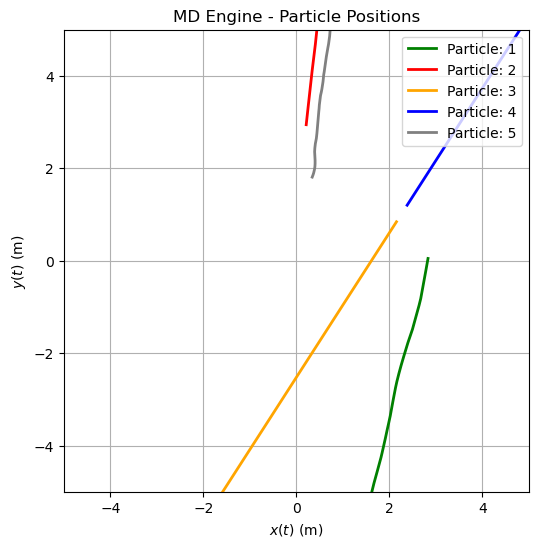

In [5]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']

for p in range(particles):
    if len(color_list) == 0:
        color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']
    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    #label = f"$ωΔt$ = {timestep:0.3f}"
    ax.plot(position[:,p,0], position[:,p,1], color = selected_color, linestyle = "-", linewidth=2, label = "Particle: " + str(p + 1))


ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') 
ax.set_xlim(-5, 5) ; ax.set_ylim(-5, 5)
ax.legend(loc="upper right") ; ax.set_title("MD Engine - Particle Positions") ; ax.grid(True) ; 

#### Task 1: Periodic Boundary Conditions (PBC)

In [6]:
def MD_Initializer(mass, kx, ky, dt, total_time, D, particles):
    '''
    Defines variables for the MD engine
    '''
    omega = np.sqrt(kx/mass)
    timestep = dt#*omega
    snapshots = int(np.floor(total_time / timestep)) + 1
    time = np.arange(snapshots, dtype=float) * timestep
    energy = np.zeros(snapshots, dtype=float)
    ke_list = np.zeros(snapshots, dtype=float)
    x_2d = np.zeros((snapshots, particles, D), dtype=float)
    v_2d = np.zeros((snapshots, particles, D), dtype=float)
    force_2d = np.zeros((snapshots, particles, D), dtype=float)
    temperature = np.zeros(snapshots, dtype=float)
    k_2d = np.array([kx, ky], dtype=float) 

    return snapshots, omega, time, timestep, energy, ke_list, x_2d, v_2d, force_2d, temperature, k_2d

def MD_Initial_Values(k_2d, mass, x, v, F, x_2d, v_2d, force_2d, ke_list, lennard_pe, energy):
    '''
    Sets the initial values for the MD engine variables'''
    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2) ; ke_0 = 0.5 * mass * np.power(v, 2)
    energy[0] = pe_0.sum() + lennard_pe + ke_0.sum() ; ke_list[0] = ke_0.sum()
    return x_2d, v_2d, force_2d, pe_0, ke_0, energy, ke_list

def Initial_Position_Velocity(mass, target_temp, particles, D, boltzmann, rand_position_scale, box_length):
    '''
    Calculates initial x and v for each particle in the MD engine
    '''

    x = rand_position_scale * np.random.rand(particles, D)
    x = Position_Wrapper(x, box_length) #PBC
    #Maxwell_Velocity_Distribution
    sigma = np.sqrt(boltzmann * target_temp / mass)
    v = np.random.normal(loc=0.0, scale=sigma, size=(particles, D))
    return x, v

    pass

def Lennard_Jones_Force(k_2d, position, lennard_sigma, epsilon, particles,box_length):
    '''
    Calculates the Lennard Jones Force for the MD Engine
    '''
    F = -k_2d * position # old harmonic force equation
    F_part = np.zeros_like(F)
    lennard_force = 0.0
    r_min = 0.8 * lennard_sigma   

    for a in range(particles): # double loop avoids double-counting pairs
        for b in range(a + 1, particles): 
            r_vector = Displacement_Wrapper(position[a],position[b], box_length) # Just the displacement vector r
            r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) #scalar distance for r

            if r < r_min:
                r = r_min

            sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6  = (lennard_sigma / r)**6

            lennard_force = 3.0 * epsilon * (2.0 * sigma_r_12 - sigma_r_6) / r #was dividing by r^2
            F_part = lennard_force * (r_vector / r)

            F[a] += F_part ; F[b] -= F_part

    return F

def Lennard_Jones_PE(k_2d, position, lennard_sigma, epsilon, particles, box_length):
    '''
    Calculates the Lennard Jones PE for the MD Engine
    '''
    lennard_pe = 0.0 # comment info above
    r_min = 0.8 * lennard_sigma

    for a in range(particles):
        for b in range(a + 1, particles):
            r_vector = Displacement_Wrapper(position[a],position[b], box_length) ; r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) # r = distance between two particles, sqrt((xa-xb)^2 + (ya-yb)^2)
            if r < r_min:
                r = r_min

            sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

            lennard_pe += (sigma_r_12 - sigma_r_6) * (epsilon/4)
            
    return lennard_pe

def Particle_Detection_Loop(snapshots, k_2d, mass, epsilon, gamma, lennard_sigma, ke_list, x_2d, v_2d, force_2d, particles, x, v, F, boltzmann, D, target_temp, energy, timestep, box_length):
    '''
    Loops MD data to calculate position, velocity, and energy at each particle snapshot
    '''
    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / mass)
    for i in range(1, snapshots):
        force_random = np.sqrt(timestep) * sigma * np.random.normal(size=(particles, 2))
       
        v_halfstep = v + (((F/mass) - gamma * v) * (timestep/2)) + force_random/2 
        x_next = x + (v_halfstep * timestep)
        x_next = Position_Wrapper(x_next, box_length) #NEW

        F = Lennard_Jones_Force(k_2d, x_next, lennard_sigma, epsilon, particles, box_length)
        f_next = F

        lennard_pe = Lennard_Jones_PE(k_2d, x_next, lennard_sigma, epsilon, particles, box_length)

        v_next = v_halfstep + (((f_next / mass) - gamma * v_halfstep) * (timestep / 2.0)) + 0.5 * force_random 

        x_2d[i] = x_next ; v_2d[i] = v_next ; force_2d[i] = f_next

        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * mass * np.power(v_next, 2)
        
        ke_list[i] = ke.sum() ; energy[i] = pe.sum() + lennard_pe + ke.sum()

        x = x_next ; v = v_next ; F = f_next

    pe_list = energy - ke_list
    temperature = (ke_list * 2) / (boltzmann * D * particles)

    return x_2d, v_2d, energy, pe_list, ke_list, temperature 

def Position_Wrapper(position, box_length): #New
    '''
    Wraps position to box_length
    '''
    return ((position + box_length/2) % box_length) - box_length/2

def Displacement_Wrapper(ri, rj, box_length): #New
    r_vector = ri - rj
    return ((r_vector + box_length/2) % box_length) - box_length/2


def Molecular_Dynamics_Engine(kx=1, ky=1, mass=1, particles=2, boltzmann=1, gamma=0.1, target_temp=1.0, dt=0.001, total_time=5, 
                        rand_position_scale=1, epsilon = 1.0, lennard_sigma = 1.0, D = 2, box_length = 5.0):
    '''
    kx : Spring constant for x position
    ky : Spring constant for y position

    mass : Mass of particle
    particles : Number of particles

    boltzmann : In the surroundings at given temperature
    gamma : Friction in system
    target_temp : Target temperature of system

    dt = 0.01 : Designated timestep
    total_time : Total runtime of system

    rand_position_scale : Scales the random initial position values of particles

    epsilon : Max strength of particle attraction
    lennard_sigma : Radius of particle
    D : # of Dimensions  
    '''
    
    snapshots, omega, time, timestep, energy, ke_list, x_2d, v_2d, force_2d, temperature, k_2d = MD_Initializer(mass, kx, ky, dt, 
                                                                                                                total_time, D, particles)
    

    x, v = Initial_Position_Velocity(mass, target_temp, particles, D, boltzmann, rand_position_scale, box_length)


    F = Lennard_Jones_Force(k_2d, x, lennard_sigma, epsilon, particles, box_length)


    lennard_pe = Lennard_Jones_PE(k_2d, x, lennard_sigma, epsilon, particles, box_length)


    x_2d, v_2d, force_2d, pe_0, ke_0, energy, ke_list = MD_Initial_Values(k_2d, mass, x, v, F, x_2d, v_2d, force_2d, 
                                                                          ke_list, lennard_pe, energy)



    x_2d, v_2d, energy, pe_list, ke_list, temperature = Particle_Detection_Loop(snapshots, k_2d, mass, epsilon, gamma, 
                                                                   lennard_sigma, ke_list, x_2d, v_2d, force_2d, 
                                                                   particles, x, v, F, boltzmann, D, target_temp, energy, timestep, box_length)


    return time, x_2d, v_2d, energy, pe_list, temperature, particles, timestep, force_2d, box_length

In [7]:
time, position, velocity, energy, potential_energy, temperature, particles, timestep, force, box_length = Molecular_Dynamics_Engine(
                                                                                                            kx = 0.0,
                                                                                                            ky = 0.0, 
                                                                                                            mass = 1.0,

                                                                                                            particles = 1,
                                                                                                            boltzmann = 1.0,
                                                                                                            gamma = 0.02,
                                                                                                            target_temp = 1, 
                                                                                                            dt = 0.005,
                                                                                                            total_time = 20.0,

                                                                                                            rand_position_scale = 3.0,   
                                                                                                            epsilon = 1.0,
                                                                                                            lennard_sigma = 1.0,
                                                                                                            D = 2,
                                                                                                            box_length = 5.0)

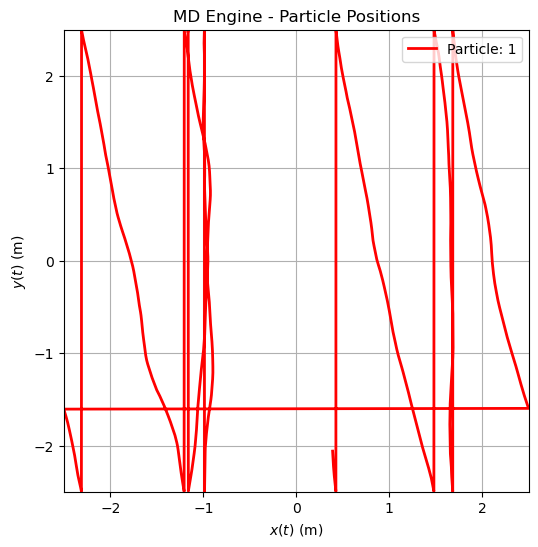

In [8]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']

for p in range(particles):
    if len(color_list) == 0:
        color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']
    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    ax.plot(position[:,p,0], position[:,p,1], color = selected_color, linestyle = "-", linewidth=2, label = "Particle: " + str(p + 1))


ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') 
ax.set_xlim(-box_length/2, box_length/2) ; ax.set_ylim(-box_length/2, box_length/2)
ax.legend(loc="upper right") ; ax.set_title("MD Engine - Particle Positions") ; ax.grid(True) ; 

In [9]:
fig, ax = plt.subplots()

scatter = ax.scatter(position[0,:,0], position[0,:,1], s=20, c= 'red') #size (s) color (c)

ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') ; 
ax.set_xlim(-box_length/2, box_length/2) ; ax.set_ylim(-box_length/2, box_length/2); ax.grid(True)
ax.set_title("MD Engine - Particle Positions") 

step = 2  # skips every other frame
frame_ind = np.arange(0, len(time), step)

def init():
    scatter.set_offsets(position[0])
    return (scatter,)

def update_data(frames): #Updates particle at each frame
    scatter.set_offsets(position[frames]) #updates scatter points
    return scatter,

writer = FFMpegWriter(fps = 30)
animation = FuncAnimation(fig, update_data, frames=frame_ind, init_func = init, blit=True) ; #HTML(animation.to_jshtml())
animation.save("PBC_OneParticle.mp4", writer=writer, dpi=80)
plt.close(fig)

In [10]:
time, position, velocity, energy, potential_energy, temperature, particles, timestep, force, box_length = Molecular_Dynamics_Engine(
                                                                                                            kx = 0.0,
                                                                                                            ky = 0.0, 
                                                                                                            mass = 1.0,

                                                                                                            particles = 30,
                                                                                                            boltzmann = 1.0,
                                                                                                            gamma = 0.02,
                                                                                                            target_temp = 1, 
                                                                                                            dt = 0.01,
                                                                                                            total_time = 40.0,

                                                                                                            rand_position_scale = 10.0,   
                                                                                                            epsilon = 1.0,
                                                                                                            lennard_sigma = 1.0,
                                                                                                            D = 2,
                                                                                                            box_length = 10.0)

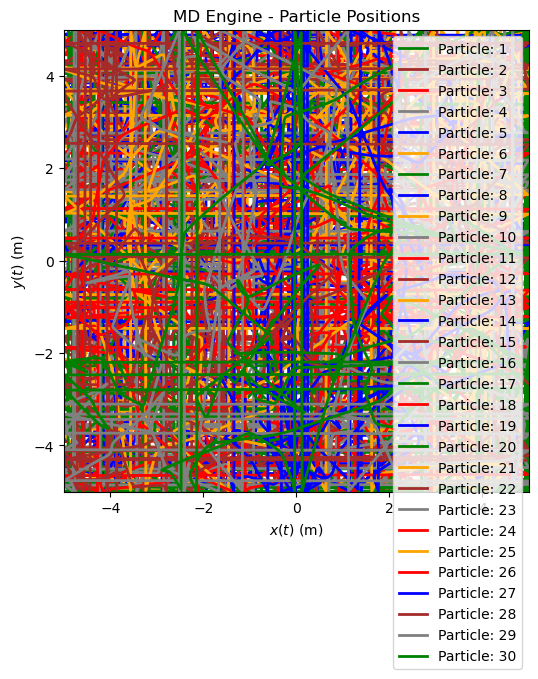

In [11]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']

for p in range(particles):
    if len(color_list) == 0:
        color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']
    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    ax.plot(position[:,p,0], position[:,p,1], color = selected_color, linestyle = "-", linewidth=2, label = "Particle: " + str(p + 1))


ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') 
ax.set_xlim(-box_length/2, box_length/2) ; ax.set_ylim(-box_length/2, box_length/2)
ax.legend(loc="upper right") ; ax.set_title("MD Engine - Particle Positions") ; ax.grid(True) ; 

In [12]:
fig, ax = plt.subplots()

scatter = ax.scatter(position[0,:,0], position[0,:,1], s=40, c= 'red') #size (s) color (c)

ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') ; 
ax.set_xlim(-box_length/2, box_length/2) ; ax.set_ylim(-box_length/2, box_length/2); ax.grid(True)
ax.set_title("MD Engine - Particle Positions") 

step = 1  # skips every other frame
frame_ind = np.arange(0, len(time), step)

def init():
    scatter.set_offsets(position[0])
    return (scatter,)

def update_data(frames): #Updates particle at each frame
    scatter.set_offsets(position[frames]) #updates scatter points
    return scatter,

writer = FFMpegWriter(fps = 30)
animation = FuncAnimation(fig, update_data, frames=frame_ind, init_func = init, blit=True) ; #HTML(animation.to_jshtml())
animation.save("PBC_MultiParticle.mp4", writer=writer, dpi=80)
plt.close(fig)

#### Task 2: Minimum Image Convention

In [2]:
def MD_Initializer(mass, kx, ky, dt, total_time, D, particles):
    '''
    Defines variables for the MD engine
    '''
    omega = np.sqrt(kx/mass)
    timestep = dt#*omega
    snapshots = int(np.floor(total_time / timestep)) + 1
    time = np.arange(snapshots, dtype=float) * timestep
    energy = np.zeros(snapshots, dtype=float)
    ke_list = np.zeros(snapshots, dtype=float)
    x_2d = np.zeros((snapshots, particles, D), dtype=float)
    v_2d = np.zeros((snapshots, particles, D), dtype=float)
    force_2d = np.zeros((snapshots, particles, D), dtype=float)
    temperature = np.zeros(v_2d.size, dtype=float)
    k_2d = np.array([kx, ky], dtype=float) 

    return snapshots, omega, time, timestep, energy, ke_list, x_2d, v_2d, force_2d, temperature, k_2d

def MD_Initial_Values(k_2d, mass, x, v, F, x_2d, v_2d, force_2d, ke_list, lennard_pe, energy):
    '''
    Sets the initial values for the MD engine variables'''
    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2) ; ke_0 = 0.5 * mass * np.power(v, 2)
    energy[0] = pe_0.sum() + lennard_pe + ke_0.sum() ; ke_list[0] = ke_0.sum()
    return x_2d, v_2d, force_2d, pe_0, ke_0, energy, ke_list

def Initial_Position_Velocity(mass, target_temp, particles, D, boltzmann, rand_position_scale, box_length):
    '''
    Calculates initial x and v for each particle in the MD engine
    '''

    x = rand_position_scale * np.random.rand(particles, D)
    x = Position_Wrapper(x, box_length) #PBC
    #Maxwell_Velocity_Distribution
    sigma = np.sqrt(boltzmann * target_temp / mass)
    v = np.random.normal(loc=0.0, scale=sigma, size=(particles, D))
    return x, v

    pass

def Lenanard_Jones_Force(k_2d, position, lennard_sigma, epsilon, particles,box_length):
    '''
    Calculates the Lennard Jones Force for the MD Engine
    '''
    F = -k_2d * position # old harmonic force equation
    F_part = np.zeros_like(F)
    lennard_force = 0.0
    r_min = 0.8 * lennard_sigma   

    for a in range(particles): # double loop avoids double-counting pairs
        for b in range(a + 1, particles): 
            r_vector = Displacement_Wrapper(position[a],position[b], box_length) # Just the displacement vector r
            r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) #scalar distance for r

            if r < r_min:
                r = r_min

            sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6  = (lennard_sigma / r)**6

            lennard_force = 3.0 * epsilon * (2.0 * sigma_r_12 - sigma_r_6) / r #was dividing by r^2
            F_part = lennard_force * (r_vector / r)

            F[a] += F_part ; F[b] -= F_part

    return F

def Lenanard_Jones_PE(k_2d, position, lennard_sigma, epsilon, particles, box_length):
    '''
    Calculates the Lennard Jones PE for the MD Engine
    '''
    lennard_pe = 0.0 # comment info above
    r_min = 0.8 * lennard_sigma

    for a in range(particles):
        for b in range(a + 1, particles):
            r_vector = Displacement_Wrapper(position[a],position[b], box_length) ; r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) # r = distance between two particles, sqrt((xa-xb)^2 + (ya-yb)^2)
            if r < r_min:
                r = r_min

            sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

            lennard_pe += (sigma_r_12 - sigma_r_6) * (epsilon/4)
            
    return lennard_pe


def Particle_Detection_Loop(snapshots, k_2d, mass, epsilon, gamma, lennard_sigma, ke_list, x_2d, v_2d, force_2d, particles, x, v, F, boltzmann, D, target_temp, energy, timestep, box_length):
    '''
    Loops MD data to calculate position, velocity, and energy at each particle snapshot
    '''
    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / mass)
    for i in range(1, snapshots):
        force_random = np.sqrt(timestep) * sigma * np.random.normal(size=(particles, 2))
       
        v_halfstep = v + (((F/mass) - gamma * v) * (timestep/2)) + force_random/2 
        x_next = x + (v_halfstep * timestep)
        x_next = Position_Wrapper(x_next, box_length) #NEW

        F = Lenanard_Jones_Force(k_2d, x_next, lennard_sigma, epsilon, particles, box_length)
        f_next = F

        lennard_pe = Lenanard_Jones_PE(k_2d, x_next, lennard_sigma, epsilon, particles, box_length)

        v_next = v_halfstep + (((f_next / mass) - gamma * v_halfstep) * (timestep / 2.0)) + 0.5 * force_random 

        x_2d[i] = x_next ; v_2d[i] = v_next ; force_2d[i] = f_next

        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * mass * np.power(v_next, 2)
        
        ke_list[i] = ke.sum() ; energy[i] = pe.sum() + lennard_pe + ke.sum()

        x = x_next ; v = v_next ; F = f_next

    pe_list = energy - ke_list
    temperature = (ke_list * 2) / (boltzmann * D * particles)

    return x_2d, v_2d, energy, pe_list, ke_list, temperature 

def Position_Wrapper(position, box_length):
    '''
    Wraps position to box_length
    '''
    return ((position + box_length/2) % box_length) - box_length/2

def Displacement_Wrapper(ri, rj, box_length): #Updated. Check later if this works

    r_vector = ri - rj
    '''for d in range(r_vector):
        
        # Adjust ri with while loop
        while ri[d] > box_length/2:
            ri[d] -= box_length
        while ri[d] < -box_length/2:
            ri[d] += box_length

        # Adjust rj with while loop
        while rj[d] > box_length/2:
            rj[d] -= box_length
        while rj[d] < -box_length/2:
            rj[d] += box_length'''

    for d in range(len(r_vector)):

        # FIX: wrap displacement, NOT particle positions
        while r_vector[d] > box_length/2:
            r_vector[d] -= box_length

        while r_vector[d] < -box_length/2:
            r_vector[d] += box_length

    return r_vector



def Molecular_Dynamics_Engine(kx=1, ky=1, mass=1, particles=2, boltzmann=1, gamma=0.1, target_temp=1.0, dt=0.001, total_time=5, 
                        rand_position_scale=1, epsilon = 1.0, lennard_sigma = 1.0, D = 2, box_length = 5.0):
    '''
    kx : Spring constant for x position
    ky : Spring constant for y position

    mass : Mass of particle
    particles : Number of particles

    boltzmann : In the surroundings at given temperature
    gamma : Friction in system
    target_temp : Target temperature of system

    dt = 0.01 : Designated timestep
    total_time : Total runtime of system

    rand_position_scale : Scales the random initial position values of particles

    epsilon : Max strength of particle attraction
    lennard_sigma : Radius of particle
    D : # of Dimensions  
    '''
    
    snapshots, omega, time, timestep, energy, ke_list, x_2d, v_2d, force_2d, temperature, k_2d = MD_Initializer(mass, kx, ky, dt, 
                                                                                                                total_time, D, particles)
    

    x, v = Initial_Position_Velocity(mass, target_temp, particles, D, boltzmann, rand_position_scale, box_length)


    F = Lenanard_Jones_Force(k_2d, x, lennard_sigma, epsilon, particles, box_length)


    lennard_pe = Lenanard_Jones_PE(k_2d, x, lennard_sigma, epsilon, particles, box_length)


    x_2d, v_2d, force_2d, pe_0, ke_0, energy, ke_list = MD_Initial_Values(k_2d, mass, x, v, F, x_2d, v_2d, force_2d, 
                                                                          ke_list, lennard_pe, energy)



    x_2d, v_2d, energy, pe_list, ke_list, temperature = Particle_Detection_Loop(snapshots, k_2d, mass, epsilon, gamma, 
                                                                   lennard_sigma, ke_list, x_2d, v_2d, force_2d, 
                                                                   particles, x, v, F, boltzmann, D, target_temp, energy, timestep, box_length)


    return time, x_2d, v_2d, energy, pe_list, temperature, particles, timestep, force_2d, box_length

In [14]:
time, position, velocity, energy, potential_energy, temperature, particles, timestep, force, box_length = Molecular_Dynamics_Engine(
                                                                                                            kx = 0.0,
                                                                                                            ky = 0.0, 
                                                                                                            mass = 1.0,

                                                                                                            particles = 30,
                                                                                                            boltzmann = 1.0,
                                                                                                            gamma = 0.02,
                                                                                                            target_temp = 1, 
                                                                                                            dt = 0.01,
                                                                                                            total_time = 30.0,

                                                                                                            rand_position_scale = 10.0,   
                                                                                                            epsilon = 1.0,
                                                                                                            lennard_sigma = 1.0,
                                                                                                            D = 2,
                                                                                                            box_length = 10.0)

In [15]:
fig, ax = plt.subplots()

scatter = ax.scatter(position[0,:,0], position[0,:,1], s=40, c= 'red') #size (s) color (c)

ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') ; 
ax.set_xlim(-box_length/2, box_length/2) ; ax.set_ylim(-box_length/2, box_length/2); ax.grid(True)
ax.set_title("MD Engine - Particle Positions") 

step = 1  # skips every other frame
frame_ind = np.arange(0, len(time), step)

def init():
    scatter.set_offsets(position[0])
    return (scatter,)

def update_data(frames): #Updates particle at each frame
    scatter.set_offsets(position[frames]) #updates scatter points
    return scatter,

writer = FFMpegWriter(fps = 30)
animation = FuncAnimation(fig, update_data, frames=frame_ind, init_func = init, blit=True) ; #HTML(animation.to_jshtml())
animation.save("PBC_Minimum_Image_Convention.mp4", writer=writer, dpi=80)
plt.close(fig)